In [3]:
import matplotlib.pyplot as plt

In [4]:
import pandas as pd

df=pd.read_excel("cleaned_online_retail.xlsx")

# Product Churn Analysis in Online Retail

This notebook analyses product-level churn behaviour using transactional sales data from an online retail business.

The project is structured to answer four major business questions:

1. Which products drive revenue and transaction volume?
2. How long do products remain commercially active?
3. Which products have churned based on inactivity?
4. How can the product portfolio be segmented into actionable business groups?

> **Note:** Detailed data cleaning was completed in a separate notebook.  
> This notebook starts from the cleaned transactional dataset and focuses on analytical modelling, lifecycle analysis, churn detection, and portfolio strategy.


## Dataset Overview

The cleaned dataset contains historical online retail transactions with the following important fields:

- `Invoice` — transaction identifier
- `StockCode` — product code
- `Description` — product description
- `Quantity` — units sold
- `InvoiceDate` — transaction timestamp
- `Price` — unit price
- `Customer ID` — buyer identifier
- `Country` — transaction geography
- `TotalAmount` — engineered revenue field (`Quantity * Price`)

Each row represents a transaction line item.  
The analysis is performed at the **product description level** where needed to reduce fragmentation across stock codes and produce more business-meaningful insights.


## Analysis Roadmap

This notebook is organised into the following phases:

- **Phase 2 — Product Performance Analysis**
- **Phase 3 — Product Lifecycle Analysis**
- **Phase 4 — Product Churn Identification**
- **Phase 5 — Sales Decline Before Churn**
- **Phase 6 — Product Segmentation**
- **Final KPI Summary, Correlation Review, and Recommendations**


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 508414 entries, 0 to 508413
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      508414 non-null  object        
 1   StockCode    77148 non-null   object        
 2   Description  505483 non-null  object        
 3   Quantity     508414 non-null  int64         
 4   InvoiceDate  508414 non-null  datetime64[ns]
 5   Price        508414 non-null  float64       
 6   Customer ID  400947 non-null  float64       
 7   Country      508414 non-null  object        
 8   TotalAmount  508414 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 34.9+ MB


In [6]:
df.size

4575726

In [7]:
df['StockCode'].nunique()

1673

In [8]:
df['Customer ID'].nunique()

4314

In [9]:
print("start date:",df['InvoiceDate'].min())
print("end date:",df['InvoiceDate'].max())

start date: 2009-12-01 07:45:00
end date: 2010-12-09 20:01:00


In [10]:
df.groupby('Country')['Invoice'].count().sort_values()

Country
lebanon                     12
nigeria                     30
bermuda                     34
korea                       53
west indies                 54
brazil                      62
iceland                     71
hong kong                   74
israel                      74
thailand                    76
canada                      77
bahrain                    106
rsa                        110
singapore                  117
lithuania                  154
japan                      164
malta                      170
poland                     182
usa                        230
unspecified                306
finland                    347
norway                     365
united arab emirates       399
denmark                    418
greece                     512
austria                    524
cyprus                     533
australia                  630
italy                      708
channel islands            821
sweden                     886
belgium                   1037


In [11]:
df['TotalAmount'].describe()

count    508414.000000
mean         19.934956
std         144.119712
min      -53594.360000
25%           4.200000
50%          10.200000
75%          17.700000
max       25111.090000
Name: TotalAmount, dtype: float64

In [12]:
df['TotalAmount'].sum()

np.float64(10135210.644000001)

In [13]:
revenue_per_invoice = df.groupby('Invoice')['TotalAmount'].sum()
revenue_per_invoice.mean()

np.float64(418.39541958388367)

In [14]:
product_summary=(
                  df.groupby('StockCode')
                  .agg(
                       total_revenue=('TotalAmount','sum'),
                       total_quantity_sold=('Quantity','sum'),
                       total_transactios=('Invoice','nunique')
                       )
                    .reset_index()
                       )

In [15]:
product_summary.head()

,StockCode,total_revenue,total_quantity_sold,total_transactios
0,10002R,20.57,4,3
1,10123C,251.81,536,62
2,10123G,165.56,2334,18
3,10124A,19.32,122,15
4,10124C,0.00,-5,1


In [16]:

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalAmount
0,489434,NaN,15cm christmas glass ball 20 lights,12,2009-12-01 07:45:00,6.95,13085.0,united kingdom,83.4
1,489434,79323P,pink cherry lights,12,2009-12-01 07:45:00,6.75,13085.0,united kingdom,81.0
2,489434,79323W,white cherry lights,12,2009-12-01 07:45:00,6.75,13085.0,united kingdom,81.0
3,489434,NaN,"record frame 7"" single size",48,2009-12-01 07:45:00,2.10,13085.0,united kingdom,100.8
4,489434,NaN,strawberry ceramic trinket box,24,2009-12-01 07:45:00,1.25,13085.0,united kingdom,30.0


## Step 3 — Product Performance Distribution (Revenue Concentration Analysis)

### Business Objective

The purpose of this analysis is to understand how revenue is distributed across products.

Key Questions:
- Do a few products generate most of the revenue?
- Is the business highly dependent on a limited number of high-performing products?

Understanding revenue concentration helps in:
- Identifying star products
- Evaluating business risk due to product dependency
- Supporting inventory and marketing strategy decisions

In [17]:
# Aggregate total revenue at product description level
# Description level is chosen to avoid revenue fragmentation across stock codes

revenue_per_product=df.groupby('Description')['TotalAmount'].sum().reset_index()

In [18]:
revenue_per_product.head()

,Description,TotalAmount
0,*boombox ipod classic,16.98
1,*usb office glitter lamp,8.65
2,*usb office mirror ball,8.65
3,10 colour spaceboy pen,5184.47
4,11 pc ceramic tea set polkadot,14.85


In [19]:
# Sort products from highest to lowest revenue
revenue_per_product=revenue_per_product.sort_values(by ='TotalAmount' ,ascending =False)

In [20]:
total_revenue=df['TotalAmount'].sum()
print(total_revenue)

10135210.644000001


In [21]:
# Calculate percentage contribution of each product to total revenue
revenue_per_product['revenue_pct']=(revenue_per_product['TotalAmount']/total_revenue)*100


In [22]:
revenue_per_product.head()

,Description,TotalAmount,revenue_pct
2398,manual,262589.86,2.590867
3374,regency cakestand 3 tier,169912.76,1.676460
4425,white hanging heart t-light holder,160345.63,1.582065
1301,dotcom postage,116408.71,1.148557
257,assorted colour bird ornament,72890.19,0.719178


In [23]:
# Calculate cumulative contribution to understand how quickly revenue accumulates
revenue_per_product['cum_revenue_pct'] =revenue_per_product['revenue_pct'].cumsum()

In [24]:
revenue_per_product.head(10)

,Description,TotalAmount,revenue_pct,cum_revenue_pct
2398,manual,262589.86,2.590867,2.590867
3374,regency cakestand 3 tier,169912.76,1.676460,4.267327
4425,white hanging heart t-light holder,160345.63,1.582065,5.849392
1301,dotcom postage,116408.71,1.148557,6.997950
257,assorted colour bird ornament,72890.19,0.719178,7.717128
2786,paper chain kit 50's christmas,58127.30,0.573518,8.290646
2156,jumbo bag red retrospot,56480.46,0.557270,8.847916
2800,party bunting,49664.12,0.490016,9.337932
3169,postage,49477.54,0.488175,9.826106
3496,rotating silver angels t-light hldr,47954.49,0.473147,10.299254


In [25]:
revenue_per_product[
    revenue_per_product['cum_revenue_pct'] <= 80
].tail()

,Description,TotalAmount,revenue_pct,cum_revenue_pct
1384,empire union jack tv dinner tray,2577.11,0.025427,79.881908
1480,"fancy font birthday card,",2576.13,0.025418,79.907326
2851,pens assorted funny face,2575.04,0.025407,79.932733
2147,joy large wood letters,2574.14,0.025398,79.958131
1932,grow a flytrap or sunflower in tin,2571.63,0.025373,79.983504


In [26]:
# Filter products contributing to first 80% of revenue

top_products_80 = revenue_per_product[
    revenue_per_product['cum_revenue_pct'] <= 80
]

# Count number of such products
num_top_products = top_products_80.shape[0]

# Total products
total_products = revenue_per_product.shape[0]

# Percentage of products generating majority revenue
pct_products = (num_top_products / total_products) * 100

print("Products generating 80% revenue:", num_top_products)
print("Total products:", total_products)
print("Percentage of products generating 80% revenue:", pct_products)

Products generating 80% revenue: 950
Total products: 4615
Percentage of products generating 80% revenue: 20.585048754062836


### Numerical Insight

The analysis shows that approximately 21% of products contribute to nearly 80% of total revenue.
This indicates a strong revenue concentration pattern where a relatively small number of products
drive the majority of business performance.

Such a distribution reflects a typical long-tail retail structure where many products generate
minimal revenue while a limited group of products act as key revenue drivers.

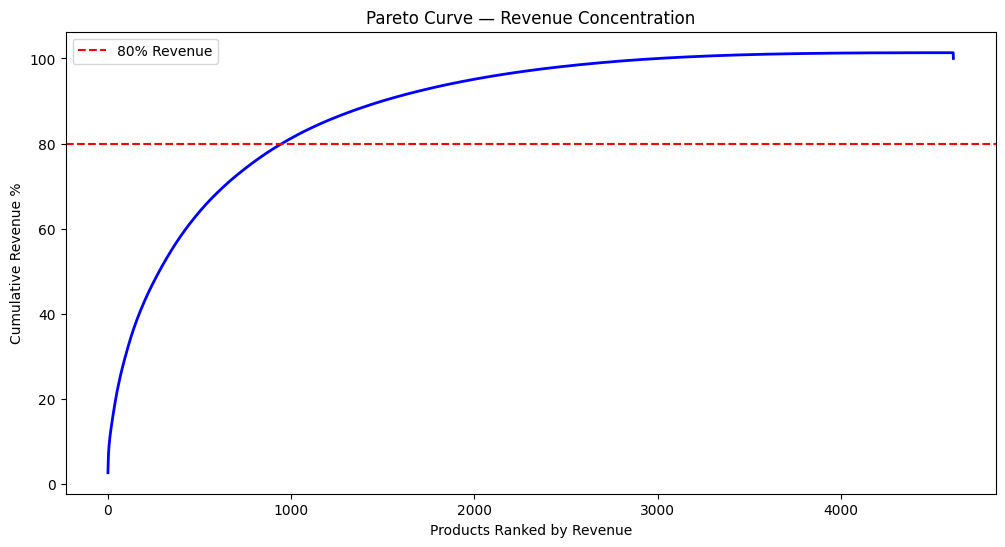

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    range(len(revenue_per_product)),
    revenue_per_product['cum_revenue_pct'],
    color='blue',
    linewidth=2
)

plt.axhline(80, color='red', linestyle='--', label='80% Revenue')

plt.title('Pareto Curve — Revenue Concentration')
plt.xlabel('Products Ranked by Revenue')
plt.ylabel('Cumulative Revenue %')

plt.legend()
plt.show()

### Visualization Insight

The Pareto curve shows a steep increase in cumulative revenue contribution for the initial set of products,
indicating that revenue accumulates rapidly among top-performing products.

The curve begins to flatten after approximately one-fifth of total products, highlighting the presence of a
long tail where a large number of products contribute only marginally to overall revenue.

This confirms that the business exhibits revenue concentration and is significantly dependent on a limited
set of high-revenue products.

In [28]:
product_demand=df.groupby('Description')['Invoice'].nunique().reset_index()

In [29]:
product_demand.head()

,Description,Invoice
0,*boombox ipod classic,1
1,*usb office glitter lamp,1
2,*usb office mirror ball,1
3,10 colour spaceboy pen,291
4,11 pc ceramic tea set polkadot,1


In [30]:
product_demand.columns = ['Description', 'total_transactions']

In [31]:
product_demand.describe()

,total_transactions
count,4615.000000
mean,108.049187
std,172.229020
min,1.000000
25%,12.000000
50%,45.000000
75%,131.500000
max,3316.000000


In [32]:
rare_product=product_demand[product_demand['total_transactions']<=5]
print(rare_product)

                             Description  total_transactions
0                  *boombox ipod classic                   1
1               *usb office glitter lamp                   1
2                *usb office mirror ball                   1
4         11 pc ceramic tea set polkadot                   1
25                       12's sold as 1?                   1
...                                  ...                 ...
4587  yellow pink flower design big bowl                   2
4594             yellow/blue retro radio                   5
4600                 zebra invcing error                   1
4603      zinc hanging heart t-lite hldr                   1
4606    zinc heart lattice charger small                   4

[710 rows x 2 columns]


In [33]:
num_rare_product = rare_product.shape[0]
total_product = product_demand.shape[0]

rare_pct = (num_rare_product / total_products) * 100

print("Rarely sold products:", num_rare_product)
print("Total products:", total_product)
print("Percentage of rare products:", rare_pct)

Rarely sold products: 710
Total products: 4615
Percentage of rare products: 15.384615384615385


In [34]:
print(num_rare_product)

710


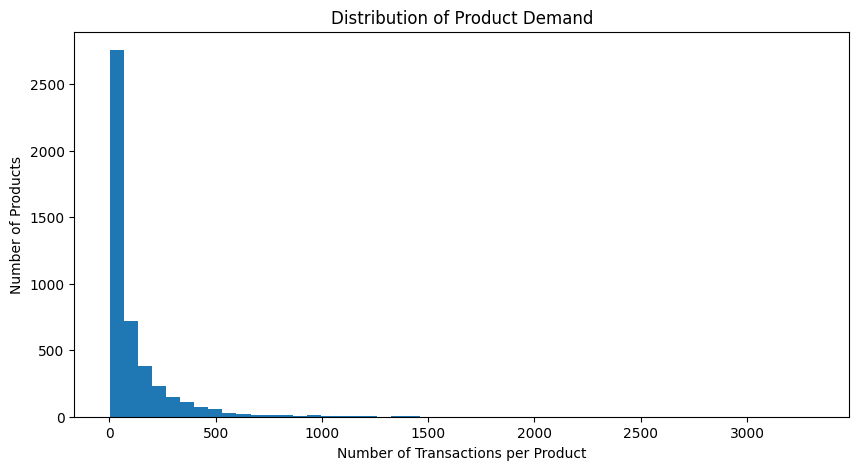

In [35]:


plt.figure(figsize=(10,5))

plt.hist(product_demand['total_transactions'], bins=50)

plt.title('Distribution of Product Demand')
plt.xlabel('Number of Transactions per Product')
plt.ylabel('Number of Products')

plt.show()

### Top Revenue-Generating Products

To identify the main revenue drivers, the top 10 products are extracted based on total revenue.

This helps highlight the products contributing most strongly to business performance.

In [36]:
# Select top 10 products by revenue
top10_revenue_products = revenue_per_product.head(10)

top10_revenue_products

,Description,TotalAmount,revenue_pct,cum_revenue_pct
2398,manual,262589.86,2.590867,2.590867
3374,regency cakestand 3 tier,169912.76,1.676460,4.267327
4425,white hanging heart t-light holder,160345.63,1.582065,5.849392
1301,dotcom postage,116408.71,1.148557,6.997950
257,assorted colour bird ornament,72890.19,0.719178,7.717128
2786,paper chain kit 50's christmas,58127.30,0.573518,8.290646
2156,jumbo bag red retrospot,56480.46,0.557270,8.847916
2800,party bunting,49664.12,0.490016,9.337932
3169,postage,49477.54,0.488175,9.826106
3496,rotating silver angels t-light hldr,47954.49,0.473147,10.299254


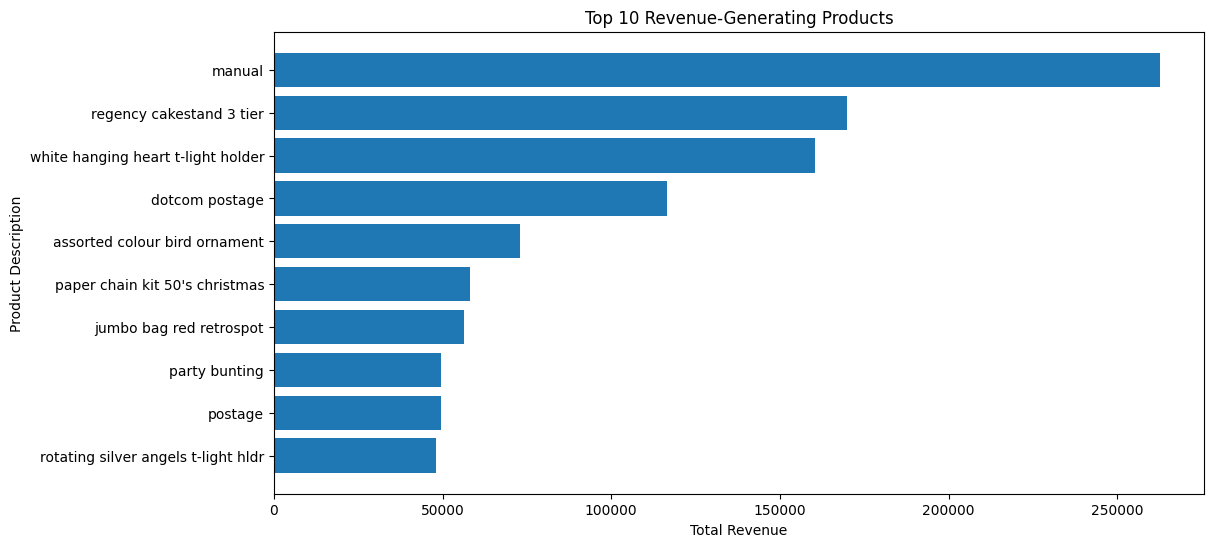

In [37]:


plt.figure(figsize=(12,6))
plt.barh(top10_revenue_products['Description'], top10_revenue_products['TotalAmount'])

plt.title('Top 10 Revenue-Generating Products')
plt.xlabel('Total Revenue')
plt.ylabel('Product Description')
plt.gca().invert_yaxis()

plt.show()

### Combined Product Performance Table

Revenue and transaction frequency are merged into a single product-level performance table.

This creates a more complete view of financial strength and market demand for each product.

In [38]:
# Merge revenue and demand tables
product_performance = revenue_per_product.merge(
    product_demand,
    on='Description',
    how='inner'
)

product_performance.head()

,Description,TotalAmount,revenue_pct,cum_revenue_pct,total_transactions
0,manual,262589.86,2.590867,2.590867,516
1,regency cakestand 3 tier,169912.76,1.676460,4.267327,2020
2,white hanging heart t-light holder,160345.63,1.582065,5.849392,3316
3,dotcom postage,116408.71,1.148557,6.997950,733
4,assorted colour bird ornament,72890.19,0.719178,7.717128,1413


##   Product Lifecycle Analysis
### Business Objective

The objective of this phase is to understand how long products remain active in the business.

Product lifecycle analysis helps in identifying:
- Short-lived products that may indicate weak demand or seasonal presence
- Long-lived products that contribute to sustained revenue generation
- Lifecycle patterns that can influence churn behaviour

### Key Questions

- When was each product first sold?
- When was each product last sold?
- How long did each product remain active in the dataset?



In [39]:
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])

In [40]:
df['InvoiceDate'].dtype

dtype('<M8[ns]')

### Feature Engineering

To evaluate lifecycle behaviour, the following features are created:

- First Sale Date → Earliest observed transaction date for a product
- Last Sale Date → Most recent observed transaction date
- Product Lifetime → Number of days between first and last sale

In [41]:
product_lifecycle=df.groupby('Description') .agg(
                         first_sale_date=('InvoiceDate','min'),
                         last_sale_date=('InvoiceDate','max')).reset_index()

In [42]:
product_lifecycle.head()

,Description,first_sale_date,last_sale_date
0,*boombox ipod classic,2010-12-09 14:09:00,2010-12-09 14:09:00
1,*usb office glitter lamp,2009-12-01 14:28:00,2009-12-01 14:28:00
2,*usb office mirror ball,2009-12-02 14:36:00,2009-12-02 14:36:00
3,10 colour spaceboy pen,2010-05-06 16:21:00,2010-12-09 13:38:00
4,11 pc ceramic tea set polkadot,2009-12-08 13:04:00,2009-12-08 13:04:00


###  Calculate Product Lifetime

Product lifetime is measured as the difference between the last observed sale date
and the first observed sale date.

A lifetime of 0 days means that the product was sold only on a single observed day.
This may indicate one-time demand, seasonal sales, experimental products, or weak product continuity.

In [43]:
product_lifecycle['product_lifetime_days']=(product_lifecycle['last_sale_date']-product_lifecycle['first_sale_date']).dt.days

In [44]:
product_lifecycle.head()

,Description,first_sale_date,last_sale_date,product_lifetime_days
0,*boombox ipod classic,2010-12-09 14:09:00,2010-12-09 14:09:00,0
1,*usb office glitter lamp,2009-12-01 14:28:00,2009-12-01 14:28:00,0
2,*usb office mirror ball,2009-12-02 14:36:00,2009-12-02 14:36:00,0
3,10 colour spaceboy pen,2010-05-06 16:21:00,2010-12-09 13:38:00,216
4,11 pc ceramic tea set polkadot,2009-12-08 13:04:00,2009-12-08 13:04:00,0


###  Average Product Lifetime

The average product lifetime provides a benchmark for understanding how long products
typically remain active in the business.

This KPI is useful for comparing short-lived and long-lived products and later supports
churn interpretation.

In [45]:
# Calculate average lifetime across all products
avg_product_lifetime = product_lifecycle['product_lifetime_days'].mean()

print("Average product lifetime (days):", avg_product_lifetime)

Average product lifetime (days): 241.74582881906827


###  Visualize Lifecycle Distribution

A histogram is used because product lifetime is a numeric variable, and the goal is to understand
its overall distribution across the product portfolio.

This chart helps identify:
- Products with very short active periods
- Products with moderate active periods
- Products that remain active for most of the dataset duration

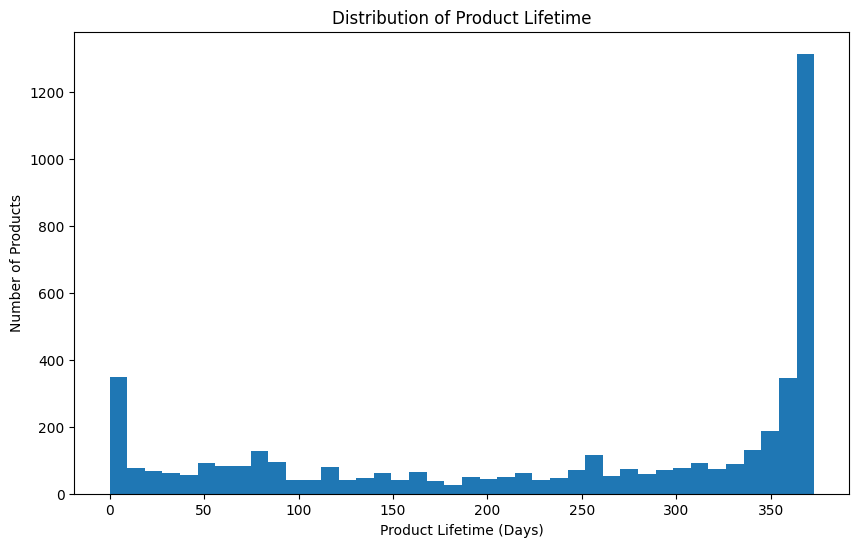

In [46]:


plt.figure(figsize=(10,6))
plt.hist(product_lifecycle['product_lifetime_days'], bins=40)

plt.title('Distribution of Product Lifetime')
plt.xlabel('Product Lifetime (Days)')
plt.ylabel('Number of Products')

plt.show()

### Lifecycle Distribution Insight

The lifecycle distribution reveals a mixed pattern.

A noticeable number of products have very short lifetimes, suggesting temporary, seasonal,
experimental, or weak-demand behaviour. At the same time, a large number of products remain active
for almost the entire dataset period, indicating the presence of stable and consistently selling items.

This dual pattern suggests that the portfolio contains both short-term and long-term products,
which is an important foundation for churn analysis.

##  Product Churn Identification

### Business Objective

The goal of this phase is to identify products that have become inactive or stopped selling.

A product is considered churned if it has not recorded any sales for a defined period.
In this analysis, a product is classified as churned if it has not been sold for more than 60 days.

This helps in:
- Detecting inactive or discontinued products
- Estimating revenue impact due to churn
- Supporting inventory and product portfolio decisions

### Churn Identification Logic

To detect churned products, the following steps are performed:

1. Identify the latest date available in the dataset (dataset observation endpoint)
2. Calculate the number of days since each product's last sale
3. Apply churn rule:
   - If days since last sale > 60 → Product is churned
   - Otherwise → Product is active

In [47]:
# Identify latest available transaction date in dataset
dataset_max_date=df['InvoiceDate'].max()
print(dataset_max_date)

2010-12-09 20:01:00


In [48]:
# Calculate inactivity period for each product
product_lifecycle['days_since_last_date']=(dataset_max_date-product_lifecycle['last_sale_date']).dt.days

In [49]:
product_lifecycle.head()

,Description,first_sale_date,last_sale_date,product_lifetime_days,days_since_last_date
0,*boombox ipod classic,2010-12-09 14:09:00,2010-12-09 14:09:00,0,0
1,*usb office glitter lamp,2009-12-01 14:28:00,2009-12-01 14:28:00,0,373
2,*usb office mirror ball,2009-12-02 14:36:00,2009-12-02 14:36:00,0,372
3,10 colour spaceboy pen,2010-05-06 16:21:00,2010-12-09 13:38:00,216,0
4,11 pc ceramic tea set polkadot,2009-12-08 13:04:00,2009-12-08 13:04:00,0,366


In [50]:
# Apply churn rule (60 days inactivity threshold)

product_lifecycle['product_churn_flag']=(product_lifecycle['days_since_last_date']>60).astype(int)
product_lifecycle.head()

,Description,first_sale_date,last_sale_date,product_lifetime_days,days_since_last_date,product_churn_flag
0,*boombox ipod classic,2010-12-09 14:09:00,2010-12-09 14:09:00,0,0,0
1,*usb office glitter lamp,2009-12-01 14:28:00,2009-12-01 14:28:00,0,373,1
2,*usb office mirror ball,2009-12-02 14:36:00,2009-12-02 14:36:00,0,372,1
3,10 colour spaceboy pen,2010-05-06 16:21:00,2010-12-09 13:38:00,216,0,0
4,11 pc ceramic tea set polkadot,2009-12-08 13:04:00,2009-12-08 13:04:00,0,366,1


### Interpretation of Churn Flag

- 1 → Product is churned (inactive for more than 60 days)
- 0 → Product is active (recently sold)

In [51]:
# Calculate product churn rate
total_products=product_lifecycle.shape[0]
churned_products=product_lifecycle['product_churn_flag'].sum()
churn_rate=(churned_products/total_products)*100
print("Total Products",total_products)
print("Churned Products",churned_products)
print("Churn Rate",churn_rate)

Total Products 4615
Churned Products 1278
Churn Rate 27.692307692307693


In [52]:
# Merge churn data with revenue data
churn_analysis=product_lifecycle.merge(revenue_per_product,on='Description',how='left')
churn_analysis.head()

,Description,first_sale_date,last_sale_date,product_lifetime_days,days_since_last_date,product_churn_flag,TotalAmount,revenue_pct,cum_revenue_pct
0,*boombox ipod classic,2010-12-09 14:09:00,2010-12-09 14:09:00,0,0,0,16.98,0.000168,101.325386
1,*usb office glitter lamp,2009-12-01 14:28:00,2009-12-01 14:28:00,0,373,1,8.65,0.000085,101.340466
2,*usb office mirror ball,2009-12-02 14:36:00,2009-12-02 14:36:00,0,372,1,8.65,0.000085,101.340381
3,10 colour spaceboy pen,2010-05-06 16:21:00,2010-12-09 13:38:00,216,0,0,5184.47,0.051153,63.777673
4,11 pc ceramic tea set polkadot,2009-12-08 13:04:00,2009-12-08 13:04:00,0,366,1,14.85,0.000147,101.330536


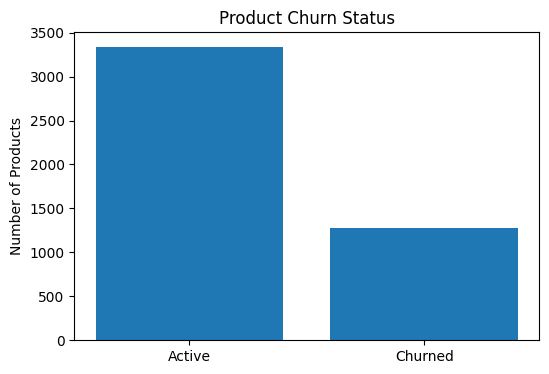

In [53]:
churn_counts = product_lifecycle['product_churn_flag'].value_counts()

plt.figure(figsize=(6,4))
plt.bar(['Active','Churned'], churn_counts)

plt.title('Product Churn Status')
plt.ylabel('Number of Products')

plt.show()

### Churn Insight

The analysis identifies products that have remained inactive for more than 60 days,
indicating potential discontinuation or demand loss.

A measurable portion of the product portfolio is affected by churn,
which can lead to reduced revenue contribution and inefficient inventory allocation.

Understanding churn magnitude helps businesses prioritize product review,
marketing interventions, or discontinuation strategies.

### Revenue Impact of Product Churn

To understand financial exposure due to churn, revenue contribution of churned and active products
is compared visually.

This helps identify the extent to which business performance is affected by inactive products.

In [54]:
# Revenue from active products
active_revenue = churn_analysis[
    churn_analysis['product_churn_flag'] == 0
]['TotalAmount'].sum()

# Revenue from churned products (already calculated but safe)
churned_revenue = churn_analysis[
    churn_analysis['product_churn_flag'] == 1
]['TotalAmount'].sum()

In [55]:
churned_revenue=churn_analysis[churn_analysis['product_churn_flag']==1]['TotalAmount'].sum()
total_revenue=churn_analysis['TotalAmount'].sum()
revenue_loss_pct=(churned_revenue/total_revenue)*100
print("Revenue from Churned Products:", churned_revenue)
print("Revenue Loss Percentage:", revenue_loss_pct)

Revenue from Churned Products: 1051729.22
Revenue Loss Percentage: 10.376984326641688


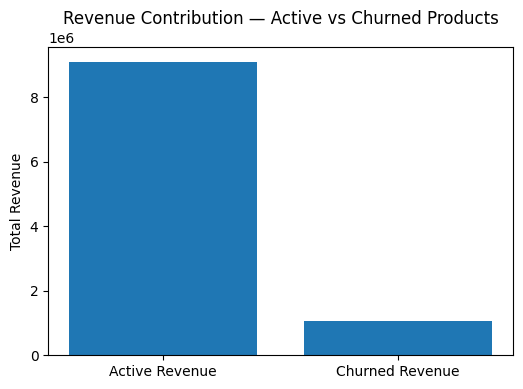

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(
    ['Active Revenue','Churned Revenue'],
    [active_revenue, churned_revenue]
)

plt.title('Revenue Contribution — Active vs Churned Products')
plt.ylabel('Total Revenue')

plt.show()

### Insight — Revenue Exposure Due to Product Churn

The revenue comparison shows that active products contribute the majority of total revenue,
indicating strong dependence on currently selling items.

However, churned products also account for a measurable portion of revenue, highlighting
potential financial exposure due to product inactivity.

Monitoring revenue contribution of churned products is essential for prioritizing product review,
reintroduction strategies, or portfolio optimization decisions.

##  Sales Decline Before Churn

### Business Objective

The objective of this phase is to understand sales behaviour leading up to product churn.

By analysing monthly sales trends of churned products, we can determine whether
products show a gradual decline in revenue before becoming inactive.

This helps in:
- Identifying early warning signals of churn
- Supporting proactive product management strategies
- Improving demand forecasting and inventory planning

### Time Aggregation

Sales data is aggregated at monthly level to observe revenue trends over time.
Monthly aggregation helps smooth daily fluctuations and reveals meaningful patterns.

In [57]:
# Create Year-Month column for time trend analysis
df['year_month']=df['InvoiceDate'].dt.to_period('M')
df[['InvoiceDate','year_month']].head()

,InvoiceDate,year_month
0,2009-12-01 07:45:00,2009-12
1,2009-12-01 07:45:00,2009-12
2,2009-12-01 07:45:00,2009-12
3,2009-12-01 07:45:00,2009-12
4,2009-12-01 07:45:00,2009-12


In [58]:
# Calculate monthly revenue per product
monthly_sales=df.groupby(['Description','year_month'])['TotalAmount'].sum().reset_index()

### Focus on Churned Products

To understand decline patterns, the analysis focuses only on products that eventually churned.
This helps detect behavioural trends prior to inactivity.

In [59]:
# Extract churned product list
churned_products = product_lifecycle[
    product_lifecycle['product_churn_flag'] == 1
]['Description']

# Filter monthly sales for churned products
churned_monthly_sales = monthly_sales[
    monthly_sales['Description'].isin(churned_products)
]

In [60]:
# Average monthly revenue trend of churned products
avg_monthly_sales = churned_monthly_sales.groupby(
    'year_month'
)['TotalAmount'].mean().reset_index()

avg_monthly_sales.head()

,year_month,TotalAmount
0,2009-12,226.350248
1,2010-01,247.303071
2,2010-02,214.507638
3,2010-03,250.662217
4,2010-04,200.954682


In [61]:
avg_monthly_sales['year_month'] = avg_monthly_sales['year_month'].astype(str)

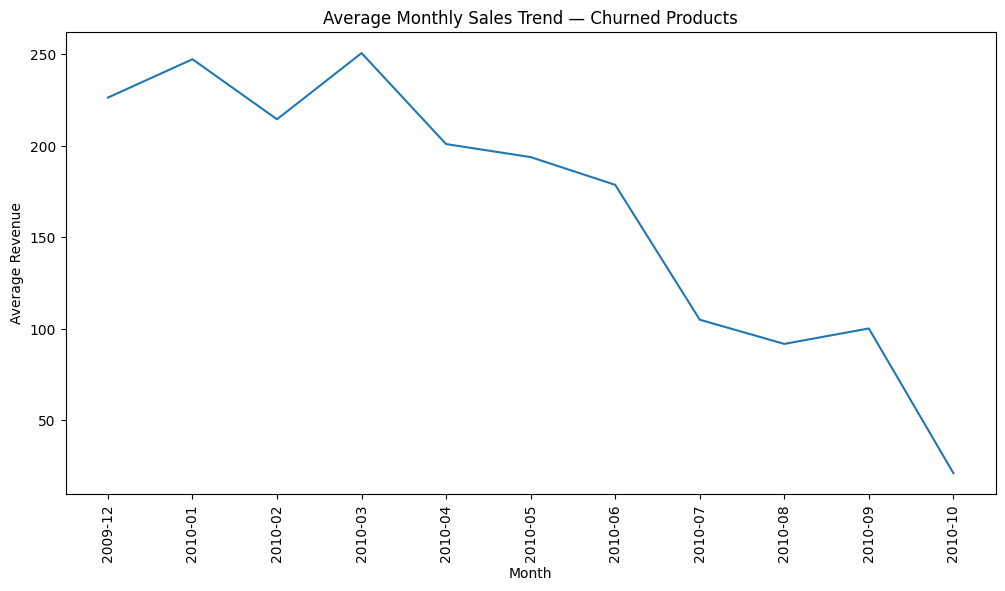

In [62]:
plt.figure(figsize=(12,6))

plt.plot(
    avg_monthly_sales['year_month'],
    avg_monthly_sales['TotalAmount']
)

plt.title('Average Monthly Sales Trend — Churned Products')
plt.xlabel('Month')
plt.ylabel('Average Revenue')

plt.xticks(rotation=90)

plt.show()

### Insight — Sales Decline Before Churn

The monthly sales trend of churned products shows a gradual decline in revenue over time,
indicating that product churn is typically preceded by weakening demand rather than occurring suddenly.

Although occasional spikes in revenue may occur due to seasonal demand or bulk purchases,
the overall downward trend suggests the presence of early warning signals prior to inactivity.

Monitoring such declining sales patterns can help businesses take proactive actions,
such as promotional interventions or portfolio optimization, to reduce churn-related revenue loss.

In [63]:
product_performance.head()

,Description,TotalAmount,revenue_pct,cum_revenue_pct,total_transactions
0,manual,262589.86,2.590867,2.590867,516
1,regency cakestand 3 tier,169912.76,1.676460,4.267327,2020
2,white hanging heart t-light holder,160345.63,1.582065,5.849392,3316
3,dotcom postage,116408.71,1.148557,6.997950,733
4,assorted colour bird ornament,72890.19,0.719178,7.717128,1413


## Product Segmentation

### Business Objective

The purpose of this phase is to categorize products based on their financial performance,
demand strength, and recent sales activity.

Segmentation helps businesses:
- Prioritize high-performing products
- Identify products at risk of churn
- Detect weak products requiring intervention
- Support portfolio optimization decisions

In [64]:
product_segmentation = product_performance.merge(
    product_lifecycle[['Description','days_since_last_date','product_churn_flag']],
    on='Description',
    how='left'
)

product_segmentation.head(100)

,Description,TotalAmount,revenue_pct,cum_revenue_pct,total_transactions,days_since_last_date,product_churn_flag
0,manual,262589.86,2.590867,2.590867,516,0,0
1,regency cakestand 3 tier,169912.76,1.676460,4.267327,2020,0,0
2,white hanging heart t-light holder,160345.63,1.582065,5.849392,3316,0,0
3,dotcom postage,116408.71,1.148557,6.997950,733,0,0
4,assorted colour bird ornament,72890.19,0.719178,7.717128,1413,0,0
...,...,...,...,...,...,...,...
95,pink cream felt craft trinket box,15952.53,0.157397,29.919501,815,0,0
96,jumbo bag woodland animals,15896.52,0.156844,30.076345,570,0,0
97,door mat red spot,15889.75,0.156778,30.233123,413,65,1
98,knitted union flag hot water bottle,15779.09,0.155686,30.388809,620,0,0


In [65]:
avg_revenue = product_segmentation['TotalAmount'].mean()
avg_transactions = product_segmentation['total_transactions'].mean()

### Segmentation Logic

Products are classified using the following rules:

- Healthy → High revenue AND high transactions AND recently sold
- At Risk → High revenue but low transactions OR inactivity increasing
- Weak → Low revenue AND low transactions but still active
- Churned → No sales for more than 60 days

In [66]:
def segment_product(row):
    
    if row['product_churn_flag'] == 1:
        return 'Churned'
    
    elif (row['TotalAmount'] >= avg_revenue) and (row['total_transactions'] >= avg_transactions):
        return 'Healthy'
    
    elif (row['TotalAmount'] >= avg_revenue) and (row['total_transactions'] < avg_transactions):
        return 'At Risk'
    
    else:
        return 'Weak'


product_segmentation['segment'] = product_segmentation.apply(segment_product, axis=1)

product_segmentation.head()

,Description,TotalAmount,revenue_pct,cum_revenue_pct,total_transactions,days_since_last_date,product_churn_flag,segment
0,manual,262589.86,2.590867,2.590867,516,0,0,Healthy
1,regency cakestand 3 tier,169912.76,1.676460,4.267327,2020,0,0,Healthy
2,white hanging heart t-light holder,160345.63,1.582065,5.849392,3316,0,0,Healthy
3,dotcom postage,116408.71,1.148557,6.997950,733,0,0,Healthy
4,assorted colour bird ornament,72890.19,0.719178,7.717128,1413,0,0,Healthy


In [67]:
segment_counts = product_segmentation['segment'].value_counts()

segment_counts

segment
Weak       2392
Churned    1278
Healthy     883
At Risk      62
Name: count, dtype: int64

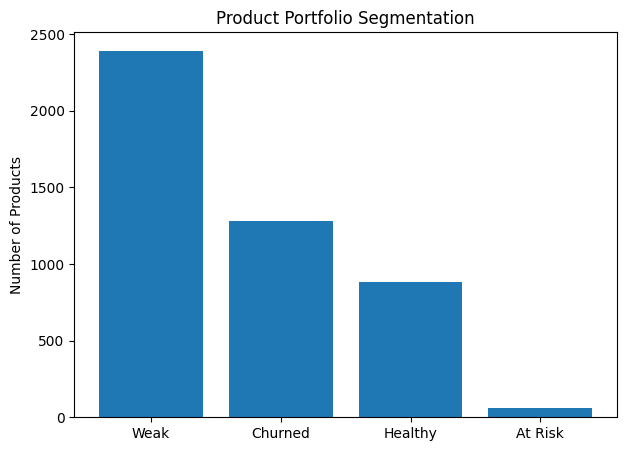

In [68]:

plt.figure(figsize=(7,5))

plt.bar(segment_counts.index, segment_counts.values)

plt.title('Product Portfolio Segmentation')
plt.ylabel('Number of Products')

plt.show()

In [69]:
segment_revenue = product_segmentation.groupby(
    'segment'
)['TotalAmount'].sum()

segment_revenue

segment
At Risk     230268.450
Churned    1051729.220
Healthy    7493526.720
Weak       1359686.254
Name: TotalAmount, dtype: float64

### Insight — Product Portfolio Segmentation

The segmentation results indicate that a substantial proportion of the product portfolio
falls into Weak and Churned categories, suggesting performance concentration risk
and potential inefficiencies in product lifecycle management.

Only a moderate share of products demonstrates strong and stable performance,
highlighting dependence on a limited number of core revenue-driving items.

The relatively small At-Risk segment suggests that products may transition quickly
from stable performance to decline or inactivity, emphasizing the importance of
early demand monitoring and proactive intervention strategies.

### Strategic Recommendations

- Focus on retaining and expanding Healthy product lines
- Monitor Weak products for repositioning or discontinuation
- Implement early-warning systems to detect sales decline
- Optimize inventory planning to reduce exposure to Churned products

## Executive KPI Summary

The following KPIs summarize the overall scale, churn magnitude, lifecycle behaviour, and revenue exposure observed in the analysis.


In [70]:
# Executive KPI summary table

executive_kpis = pd.DataFrame({
    'KPI': [
        'Total Products',
        'Churned Products',
        'Product Churn Rate (%)',
        'Average Product Lifetime (Days)',
        'Average Revenue per Product',
        'Average Transactions per Product',
        'Revenue from Churned Products',
        'Revenue Loss due to Churn (%)'
    ],
    'Value': [
        product_lifecycle.shape[0],
        product_lifecycle['product_churn_flag'].sum(),
        round((product_lifecycle['product_churn_flag'].sum() / product_lifecycle.shape[0]) * 100, 2),
        round(product_lifecycle['product_lifetime_days'].mean(), 2),
        round(revenue_per_product['TotalAmount'].mean(), 2),
        round(product_demand['total_transactions'].mean(), 2),
        round(churn_analysis[churn_analysis['product_churn_flag'] == 1]['TotalAmount'].sum(), 2),
        round(
            (
                churn_analysis[churn_analysis['product_churn_flag'] == 1]['TotalAmount'].sum()
                / churn_analysis['TotalAmount'].sum()
            ) * 100,
            2
        )
    ]
})

executive_kpis


,KPI,Value
0,Total Products,4615.00
1,Churned Products,1278.00
2,Product Churn Rate (%),27.69
3,Average Product Lifetime (Days),241.75
4,Average Revenue per Product,2196.15
5,Average Transactions per Product,108.05
6,Revenue from Churned Products,1051729.22
7,Revenue Loss due to Churn (%),10.38


## Enhanced Product Segmentation (Recency-Aware)

The initial segmentation classifies products based on revenue, demand, and churn status.  
A more realistic portfolio view can also incorporate **recent inactivity**.

Enhanced segment logic:

- **Churned** → no sales for more than 60 days
- **Healthy** → above-average revenue, above-average transactions, and recently sold
- **At Risk** → not churned, but inactivity is rising or one core metric is weakening
- **Weak** → low revenue and low transaction strength, even if currently active


In [71]:
# Enhanced segmentation using revenue, transactions, and recency together

recency_threshold = 30

def enhanced_segment(row):
    if row['product_churn_flag'] == 1:
        return 'Churned'
    elif (
        row['TotalAmount'] >= avg_revenue and
        row['total_transactions'] >= avg_transactions and
        row['days_since_last_date'] <= recency_threshold
    ):
        return 'Healthy'
    elif (
        row['days_since_last_date'] > recency_threshold or
        (row['TotalAmount'] >= avg_revenue and row['total_transactions'] < avg_transactions) or
        (row['TotalAmount'] < avg_revenue and row['total_transactions'] >= avg_transactions)
    ):
        return 'At Risk'
    else:
        return 'Weak'

product_segmentation['enhanced_segment'] = product_segmentation.apply(enhanced_segment, axis=1)

product_segmentation[['Description', 'TotalAmount', 'total_transactions', 'days_since_last_date', 'enhanced_segment']].head()


,Description,TotalAmount,total_transactions,days_since_last_date,enhanced_segment
0,manual,262589.86,516,0,Healthy
1,regency cakestand 3 tier,169912.76,2020,0,Healthy
2,white hanging heart t-light holder,160345.63,3316,0,Healthy
3,dotcom postage,116408.71,733,0,Healthy
4,assorted colour bird ornament,72890.19,1413,0,Healthy


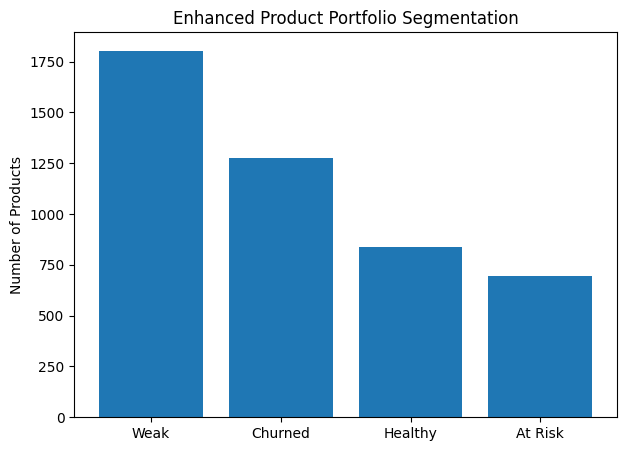

enhanced_segment
Weak       1804
Churned    1278
Healthy     837
At Risk     696
Name: count, dtype: int64

In [72]:
# Distribution of enhanced product segments

enhanced_segment_counts = product_segmentation['enhanced_segment'].value_counts()

plt.figure(figsize=(7, 5))
plt.bar(enhanced_segment_counts.index, enhanced_segment_counts.values)
plt.title('Enhanced Product Portfolio Segmentation')
plt.ylabel('Number of Products')
plt.show()

enhanced_segment_counts


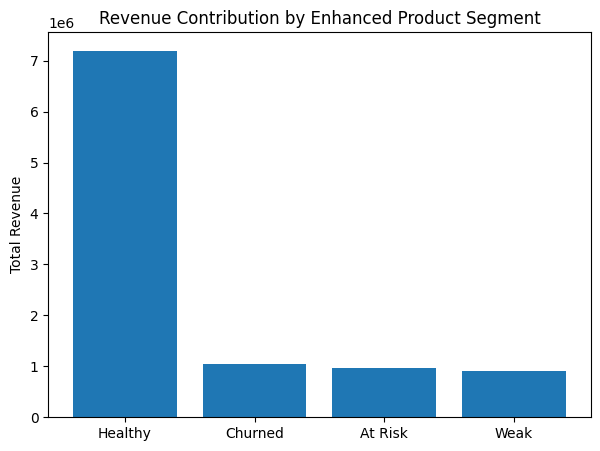

enhanced_segment
Healthy    7195904.890
Churned    1051729.220
At Risk     970841.270
Weak        916735.264
Name: TotalAmount, dtype: float64

In [73]:
# Revenue contribution by enhanced segment

enhanced_segment_revenue = product_segmentation.groupby('enhanced_segment')['TotalAmount'].sum().sort_values(ascending=False)

plt.figure(figsize=(7, 5))
plt.bar(enhanced_segment_revenue.index, enhanced_segment_revenue.values)
plt.title('Revenue Contribution by Enhanced Product Segment')
plt.ylabel('Total Revenue')
plt.show()

enhanced_segment_revenue


## Final Business Recommendations

Based on the full analysis, the following actions are recommended:

1. **Protect Healthy products** through availability planning, visibility, and sustained promotion.
2. **Monitor At-Risk products early** using recency and sales-decline signals before they enter churn.
3. **Review Weak products** for repositioning, bundling, price changes, or discontinuation.
4. **Minimize revenue exposure from Churned products** by identifying replacement products or corrective actions.
5. **Track recency, revenue, and transaction KPIs together** rather than using any single metric in isolation.


## Final Conclusion

This project demonstrates an end-to-end product churn analysis workflow using transactional retail data.

Major findings include:

- Revenue is concentrated among a relatively small subset of products.
- Product demand follows a long-tail structure with many weaker contributors.
- Product lifecycle varies widely across the portfolio.
- Churn can be identified through inactivity thresholds and quantified through both product count and revenue exposure.
- Churned products show evidence of sales decline before becoming inactive.
- Portfolio segmentation helps translate analytics into concrete business actions.

Overall, the analysis provides a strong framework for product portfolio monitoring, churn reduction, and revenue protection in a retail environment.


## Power BI Final Dataset Preparation

To build the dashboard efficiently in Power BI, the transaction-level data is consolidated into **one product-level dataset**.

### Objective
Create a single final table where each row represents one product and contains:

- product identifiers
- performance metrics
- lifecycle metrics
- churn metrics
- segmentation labels
- dashboard-friendly derived features

This dataset can be exported directly and used as the primary Power BI source file.


In [74]:
# Create dashboard-friendly product identifiers and quantity totals

# Use the most frequent StockCode observed for each Description
stockcode_per_product = (
    df.groupby('Description')['StockCode']
      .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0])
      .reset_index()
      .rename(columns={'StockCode': 'StockCode'})
)

# Total quantity sold per product
quantity_per_product = (
    df.groupby('Description')['Quantity']
      .sum()
      .reset_index()
      .rename(columns={'Quantity': 'total_quantity_sold'})
)

stockcode_per_product.head(), quantity_per_product.head()


(                      Description StockCode
 0           *boombox ipod classic       NaN
 1        *usb office glitter lamp       NaN
 2         *usb office mirror ball       NaN
 3          10 colour spaceboy pen       NaN
 4  11 pc ceramic tea set polkadot       NaN,
                       Description  total_quantity_sold
 0           *boombox ipod classic                    1
 1        *usb office glitter lamp                    1
 2         *usb office mirror ball                    1
 3          10 colour spaceboy pen                 6142
 4  11 pc ceramic tea set polkadot                    3)

### Additional Dashboard Features

A few dashboard-oriented features are added to improve Power BI usability:

- **Churn_Status** → readable active/churned label
- **Revenue_per_Transaction** → average revenue generated per transaction
- **Revenue_Tier** → low / medium / high revenue grouping
- **Lifetime_Tier** → short / medium / long lifecycle grouping
- **Activity_Status** → active / at risk / inactive based on recency


In [75]:
# Build the final product-level dataset by merging all key analysis outputs

final_product_dataset = product_performance.copy()

# Merge lifecycle + churn information
final_product_dataset = final_product_dataset.merge(
    product_lifecycle[
        ['Description',
         'first_sale_date',
         'last_sale_date',
         'product_lifetime_days',
         'days_since_last_date',
         'product_churn_flag']
    ],
    on='Description',
    how='left'
)

# Merge the enhanced segment if available, otherwise use the base segment
segment_column = 'enhanced_segment' if 'enhanced_segment' in product_segmentation.columns else 'segment'

final_product_dataset = final_product_dataset.merge(
    product_segmentation[['Description', segment_column]].drop_duplicates(),
    on='Description',
    how='left'
)

# Merge StockCode and quantity
final_product_dataset = final_product_dataset.merge(
    stockcode_per_product,
    on='Description',
    how='left'
)

final_product_dataset = final_product_dataset.merge(
    quantity_per_product,
    on='Description',
    how='left'
)

# Readable churn label
final_product_dataset['Churn_Status'] = final_product_dataset['product_churn_flag'].map({
    1: 'Churned',
    0: 'Active'
})

# Revenue per transaction
final_product_dataset['Revenue_per_Transaction'] = (
    final_product_dataset['TotalAmount'] / final_product_dataset['total_transactions']
)

# Revenue tier based on quartiles
revenue_q1 = final_product_dataset['TotalAmount'].quantile(0.25)
revenue_q3 = final_product_dataset['TotalAmount'].quantile(0.75)

def revenue_tier(x):
    if x >= revenue_q3:
        return 'High'
    elif x >= revenue_q1:
        return 'Medium'
    else:
        return 'Low'

final_product_dataset['Revenue_Tier'] = final_product_dataset['TotalAmount'].apply(revenue_tier)

# Lifetime tier
def lifetime_tier(x):
    if x > 500:
        return 'Long'
    elif x > 100:
        return 'Medium'
    else:
        return 'Short'

final_product_dataset['Lifetime_Tier'] = final_product_dataset['product_lifetime_days'].apply(lifetime_tier)

# Activity status from recency
def activity_status(days):
    if days <= 30:
        return 'Active'
    elif days <= 60:
        return 'At Risk'
    else:
        return 'Inactive'

final_product_dataset['Activity_Status'] = final_product_dataset['days_since_last_date'].apply(activity_status)

# Rename columns for dashboard clarity
final_product_dataset = final_product_dataset.rename(columns={
    'TotalAmount': 'total_revenue',
    'total_transactions': 'total_transactions',
    'product_lifetime_days': 'product_lifetime_days',
    'days_since_last_date': 'days_since_last_sale',
    'product_churn_flag': 'is_churned',
    segment_column: 'segment'
})

# Fill any numeric nulls created by division/merge
final_product_dataset['Revenue_per_Transaction'] = final_product_dataset['Revenue_per_Transaction'].fillna(0)
final_product_dataset['total_quantity_sold'] = final_product_dataset['total_quantity_sold'].fillna(0)

# Reorder columns
final_columns = [
    'StockCode',
    'Description',
    'total_revenue',
    'total_quantity_sold',
    'total_transactions',
    'Revenue_per_Transaction',
    'first_sale_date',
    'last_sale_date',
    'product_lifetime_days',
    'Lifetime_Tier',
    'days_since_last_sale',
    'Activity_Status',
    'is_churned',
    'Churn_Status',
    'segment',
    'Revenue_Tier'
]

final_product_dataset = final_product_dataset[final_columns]

final_product_dataset.head()


,StockCode,Description,total_revenue,total_quantity_sold,total_transactions,Revenue_per_Transaction,first_sale_date,last_sale_date,product_lifetime_days,Lifetime_Tier,days_since_last_sale,Activity_Status,is_churned,Churn_Status,segment,Revenue_Tier
0,M,manual,262589.86,2769,516,508.895078,2009-12-01 14:50:00,2010-12-09 16:11:00,373,Medium,0,Active,0,Active,Healthy,High
1,NaN,regency cakestand 3 tier,169912.76,13691,2020,84.115228,2010-03-15 13:55:00,2010-12-09 16:53:00,269,Medium,0,Active,0,Active,Healthy,High
2,85123A,white hanging heart t-light holder,160345.63,58692,3316,48.355136,2009-12-01 09:46:00,2010-12-09 18:09:00,373,Medium,0,Active,0,Active,Healthy,High
3,DOT,dotcom postage,116408.71,733,733,158.811337,2009-12-01 14:28:00,2010-12-09 16:35:00,373,Medium,0,Active,0,Active,Healthy,High
4,NaN,assorted colour bird ornament,72890.19,45236,1413,51.585414,2009-12-01 09:06:00,2010-12-09 19:32:00,373,Medium,0,Active,0,Active,Healthy,High


### Final Dataset Validation

Before export, the final dataset is checked to confirm:

- one row per product
- correct column structure
- no unexpected missing values in major dashboard fields


In [76]:
# Validate the final dataset

print('Shape:', final_product_dataset.shape)
print('\nDuplicate product descriptions:', final_product_dataset['Description'].duplicated().sum())
print('\nMissing values by column:')
print(final_product_dataset.isnull().sum())

final_product_dataset.info()


Shape: (4615, 16)

Duplicate product descriptions: 0

Missing values by column:
StockCode                  3182
Description                   0
total_revenue                 0
total_quantity_sold           0
total_transactions            0
Revenue_per_Transaction       0
first_sale_date               0
last_sale_date                0
product_lifetime_days         0
Lifetime_Tier                 0
days_since_last_sale          0
Activity_Status               0
is_churned                    0
Churn_Status                  0
segment                       0
Revenue_Tier                  0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4615 entries, 0 to 4614
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   StockCode                1433 non-null   object        
 1   Description              4615 non-null   object        
 2   total_revenue            4615 non-null 

### 




Export Final Dataset for Power BI

The final dataset is exported as a CSV file so it can be loaded directly into Power BI Desktop.


In [77]:
# Export the final Power BI dataset

final_product_dataset.to_csv('final_product_dashboard_dataset.csv', index=False)

print('Saved file: final_product_dashboard_dataset.csv')


Saved file: final_product_dashboard_dataset.csv
